In [1]:
import os
import glob
import gc
import random

from pathlib import Path

import numpy as np
import pandas as pd
import h5py

from scipy.sparse import csr_matrix
from pathlib import Path

import scipy

from scipy.stats import median_abs_deviation, percentileofscore

import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import seaborn as sns

import anndata as ad
import scanpy.external as sce
import scanpy as sc

import pegasus as pg
from pegasusio import UnimodalData, MultimodalData
import scrublet as scr

from tqdm import tqdm

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

In [2]:
glob.glob('/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM*')

## note: GEO Files do not contain extra metadata ##

['/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306931_Control_1_matrix.mtx.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306931_Control_1_features.tsv.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306934_Patient_2_matrix.mtx.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306931_Control_1_barcodes.tsv.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306933_Patient_1_matrix.mtx.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306932_Control_2_matrix.mtx.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306933_Patient_1_features.tsv.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306934_Patient_2_barcodes.tsv.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306933_Patient_1_barcodes.tsv.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_fil

In [3]:
glob.glob('/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM*matrix*')

['/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306931_Control_1_matrix.mtx.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306934_Patient_2_matrix.mtx.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306933_Patient_1_matrix.mtx.gz',
 '/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM4306932_Control_2_matrix.mtx.gz']

In [4]:
MATRIX_PATHS = glob.glob('/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/GEO_files/GSM*matrix*')

sample_list = []

for matrix_path in MATRIX_PATHS:
    
    file_structure = "_".join(matrix_path.split('_')[0:-1])
    sample_name = matrix_path.split('/')[-1].split('_')[0]
    
    adata = None
    adata = sc.read_mtx(matrix_path).T
    adata.var = pd.read_csv(file_structure + "_features.tsv.gz", delimiter="\t", header=None, names=['gene_symbols', 'assay'])
    adata.obs = pd.read_csv(file_structure + "_barcodes.tsv.gz", header=None, index_col=0, names=['barcodes'])
    adata.obs_names = [sample_name + '_' + obs_name for obs_name in adata.obs_names] 
    adata.obs['library'] = sample_name

    sample_list.append(adata)

khan_adata = sc.concat(sample_list, join='outer', label="library")
khan_adata.var['feature_types'] = 'Gene Expression'
khan_adata.obs['Sample_Name'] = pd.Series(khan_adata.obs_names).str.split('_').apply(lambda x: x[0]).values

In [5]:
## Add Patient Metadata ##

## Directly from GEO Website ##

SAMPLE_PATIENT_DICT = {'GSM4306931':'Control_1', 'GSM4306934':'Patient_2', 'GSM4306933':'Patient_1', 'GSM4306932': 'Control_2'}
SAMPLE_DONOR_DICT = {'GSM4306931':'0524-1', 'GSM4306934':'6303-5', 'GSM4306933':'7958-3', 'GSM4306932':'0307-1'}

khan_adata.obs['Patient'] = khan_adata.obs['Sample_Name'].apply(lambda x: SAMPLE_PATIENT_DICT[x])
khan_adata.obs['Cell_Line'] = khan_adata.obs['Sample_Name'].apply(lambda x: SAMPLE_DONOR_DICT[x])
khan_adata.obs['Donor'] = khan_adata.obs['Cell_Line'].str.split('-').apply(lambda x: x[0])
khan_adata.obs['barcodes'] = khan_adata.obs_names

In [6]:
## Donor Metadata From Supplementary Table 1 of Paper ##

khan_donor_metadata = pd.read_csv('/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/metadata/Khan_Donor_Metadata.csv')
khan_donor_metadata.rename({'Subject_ID':'Donor'}, inplace=True, axis=1)

khan_adata.obs = khan_adata.obs.merge(khan_donor_metadata, 
                                            left_on='Donor', 
                                            right_on='Donor', how='left').set_index('barcodes')

khan_adata.obs['Age'] = khan_adata.obs['Age'].str.strip(' ys').astype('int')

In [7]:
## Donor Reprogramming Metadata From Supplementary Table 2 of Paper (reduced columns)  ##

khan_reprogramming_metadata = pd.read_csv('/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/metadata/Khan_Donor_Reprogramming_Metadata.csv')
khan_reprogramming_metadata = khan_reprogramming_metadata[['hiPS cell line', 'Method of reprogramming', 'Disease']]
khan_reprogramming_metadata['hiPS cell line'] = khan_reprogramming_metadata['hiPS cell line'].str.replace('–','-')
khan_reprogramming_metadata.rename({'hiPS cell line':'Cell_Line'}, axis=1, inplace=True)

khan_adata.obs['barcodes'] = khan_adata.obs_names
khan_adata.obs = khan_adata.obs.merge(khan_reprogramming_metadata, 
                                            left_on='Cell_Line', 
                                            right_on='Cell_Line', how='left').set_index('barcodes')

In [8]:
## Coordinates of CNVs in SNP array From Supplementary Table 4 of Paper ##

khan_coordinates = pd.read_csv('/mnt/sda/scz_meta_analysis/khan_pasca_nature_med_2021/metadata/Khan_Line_Deletion_Metadata.csv')
khan_coordinates.rename({'hiPS cell lines':'Cell_Line'}, inplace=True, axis=1)
khan_adata.obs['barcodes'] = khan_adata.obs_names
khan_adata.obs = khan_adata.obs.merge(khan_coordinates, left_on='Cell_Line', right_on='Cell_Line', how='left').set_index('barcodes')

In [9]:
khan_adata

AnnData object with n_obs × n_vars = 45300 × 33538
    obs: 'library', 'Sample_Name', 'Patient', 'Cell_Line', 'Donor', 'Group', 'Sex', 'Age', 'Diagnosis', 'IQ', 'IQ_Measure', 'Method of reprogramming', 'Disease', 'Coordinates (hg19)', 'Length(bp)'
    var: 'feature_types'

In [10]:
## Map NCBI Gene Names w/Prasanth's File ##

# load prasanth's annotation file
prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')

# merge prasanth's gene info into the var dataframe
khan_adata.var['ensembl_gene_id'] = khan_adata.var.index
#del khan_adata.var['gene_name']
khan_adata.var = khan_adata.var.merge(prasanth_annot, left_on='ensembl_gene_id', right_on='ensembl_gene_id', how='left')
khan_adata.var.chromosome_name = khan_adata.var.chromosome_name.astype('str')

# fix gene name that is NaN
khan_adata.var.loc[khan_adata.var['hgnc_symbol'].isna(),'hgnc_symbol'] = khan_adata.var.loc[khan_adata.var['hgnc_symbol'].isna(),'ensembl_gene_id']

#reset the index as the hgnc_symbol
khan_adata.var.index = khan_adata.var['hgnc_symbol']
khan_adata.var.index.name = None

#some ensembls map to same hgnc so we make them unique
khan_adata.var_names_make_unique(join='#')

gc.collect()

/tmp/ipykernel_4140612/904864339.py:4: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  prasanth_annot = pd.read_csv('/home/deepak/datasets/annotations/all_genes_EnsemblInfo_104.csv')


53

In [11]:
print(khan_adata.obs.shape[0])
print(khan_adata.obs['Sex'].value_counts())

## Note of of the Donor IDs don't have a Sex ##
# We will need to Impute Later ##

45300
Sex
Female    41290
Male       4010
Name: count, dtype: int64


In [12]:
## Remove Duplicate Barcodes ##

print(khan_adata.obs_names.duplicated(keep=False).any())
print(khan_adata.var_names.duplicated(keep=False).any())

# None

False
False


In [13]:
## Set Up QC Metrics ##

# filter on robust genes
# annotate_robust_genes_scanpy(integrated, percent_cells=0.05)
pg.identify_robust_genes(khan_adata, percent_cells=0.05)
khan_adata = khan_adata[:,khan_adata.var['robust']].copy()
gc.collect()

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
khan_adata.var["mt"] = khan_adata.var_names.str.startswith("MT-")
# ribosomal genes
khan_adata.var["ribo"] = khan_adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
khan_adata.var["hb"] = khan_adata.var_names.str.contains("^HB[^(P)]")

# add protein_coding genes
khan_adata.var['protein_coding'] = khan_adata.var['gene_biotype'].apply(lambda x: True if 'protein_coding' == x else False)
khan_adata.var['protein_coding'] = khan_adata.var['protein_coding'].astype('bool')

# define mitocarta_genes
mitocarta_df = pd.read_csv('/home/deepak/datasets/annotations/Human.MitoCarta3.0.csv')
khan_adata.var['mitocarta'] = [True if x in list(mitocarta_df['Symbol']) else False for x in khan_adata.var.index]

# define robust_protein_coding genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
khan_adata.var['robust_protein_coding'] = khan_adata.var['robust'] & khan_adata.var['protein_coding']
khan_adata.var.loc[khan_adata.var.ribo, 'robust_protein_coding'] = False
khan_adata.var.loc[khan_adata.var.mt, 'robust_protein_coding'] = False
khan_adata.var.loc[khan_adata.var.mitocarta, 'robust_protein_coding'] = False

# define robust_protein_coding_autosome genes (exclude ribosomal (RPL,RPS), mitochondrial, or mitocarta genes
khan_adata.var['autosome'] = khan_adata.var.chromosome_name.isin([str(i) for i in range(1,23)])
khan_adata.var['robust_protein_coding_autosome'] = khan_adata.var['robust_protein_coding'] & khan_adata.var['autosome'] 

2026-01-31 15:20:32,509 - pegasus.tools.preprocessing - INFO - After filtration, 25398/33538 genes are kept. Among 25398 genes, 18093 genes are robust.
2026-01-31 15:20:32,510 - pegasus.tools.preprocessing - INFO - Function 'identify_robust_genes' finished in 0.36s.


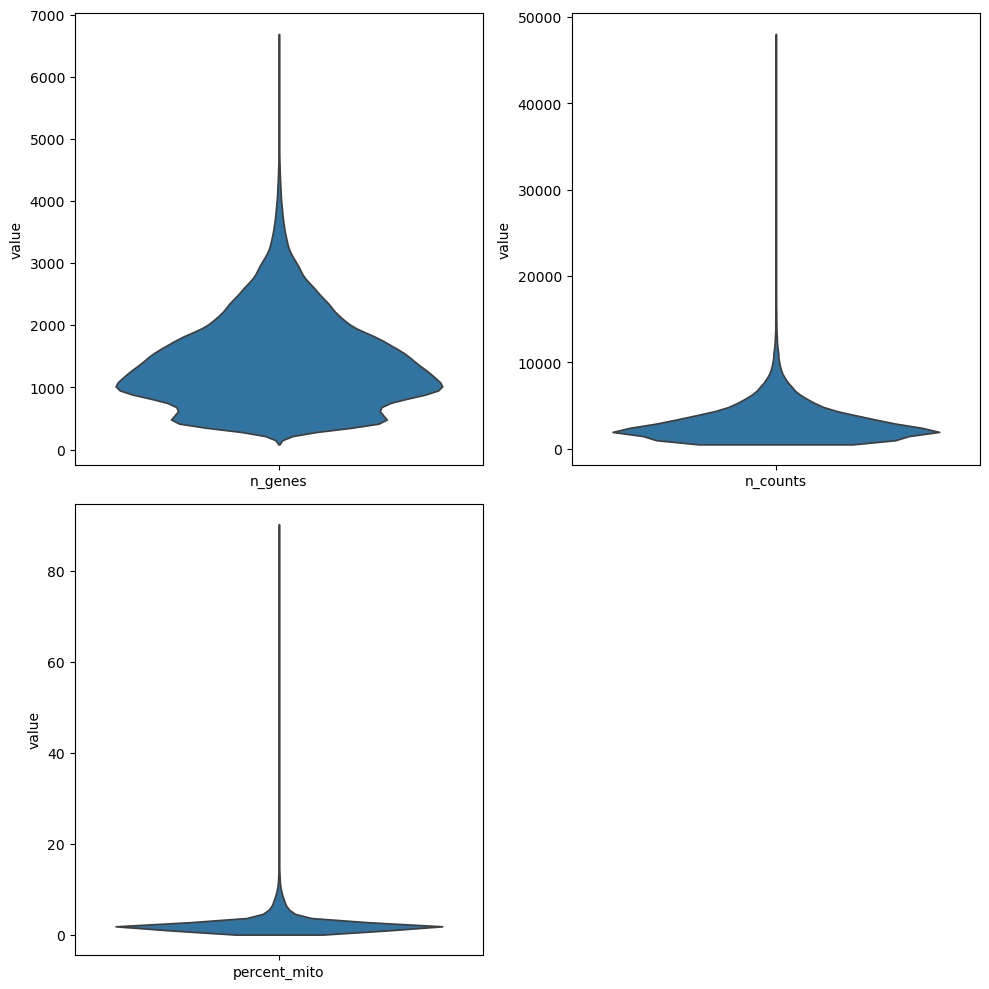

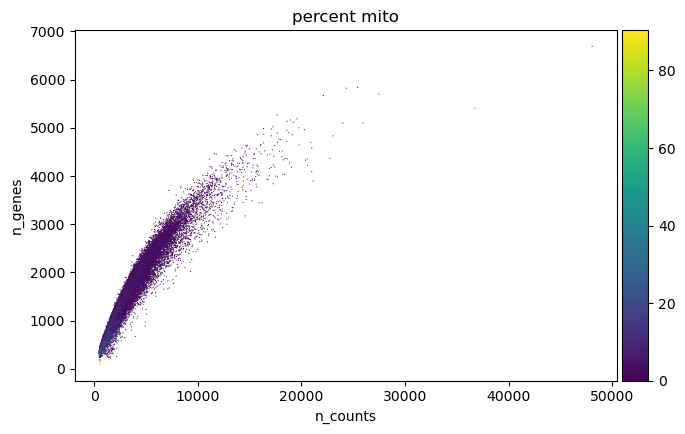

The 99th percentile all sample genes/cell is: 2774.0
The 99th percentile all sample total counts/cell is: 7191.0
The 99th percentile all sample mitochondrial % /cell is: 6.239168167114258


In [14]:
## Plot QC Metrics ##

# QC by counts #
# convert to pegasus unimodal object
khan_adata = UnimodalData(khan_adata)
pg.qc_metrics(khan_adata, mito_prefix='MT-')

# Create a figure with 3 subplots

# convert back for plotting to scanpy anndata
khan_adata = khan_adata.to_anndata()
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sc.pl.violin(khan_adata, "n_genes", ax=axes[0], show=False, stripplot=False)
sc.pl.violin(khan_adata, "n_counts", ax=axes[1], show=False, stripplot=False)
sc.pl.violin(khan_adata, "percent_mito", ax=axes[2], show=False, stripplot=False)
fig.delaxes(axes[3])
plt.tight_layout()

sc.pl.scatter(khan_adata, "n_counts", "n_genes", color="percent_mito")

print('The 99th percentile all sample genes/cell is: {0}'.format(np.percentile(khan_adata.obs['n_genes'], 95)))

print('The 99th percentile all sample total counts/cell is: {0}'.format(np.percentile(khan_adata.obs['n_counts'], 95)))

print('The 99th percentile all sample mitochondrial % /cell is: {0}'.format(np.percentile(khan_adata.obs['percent_mito'], 95)))

n_UMIs lower: 676 upper: 9636
n_genes lower: 450 upper: 3742


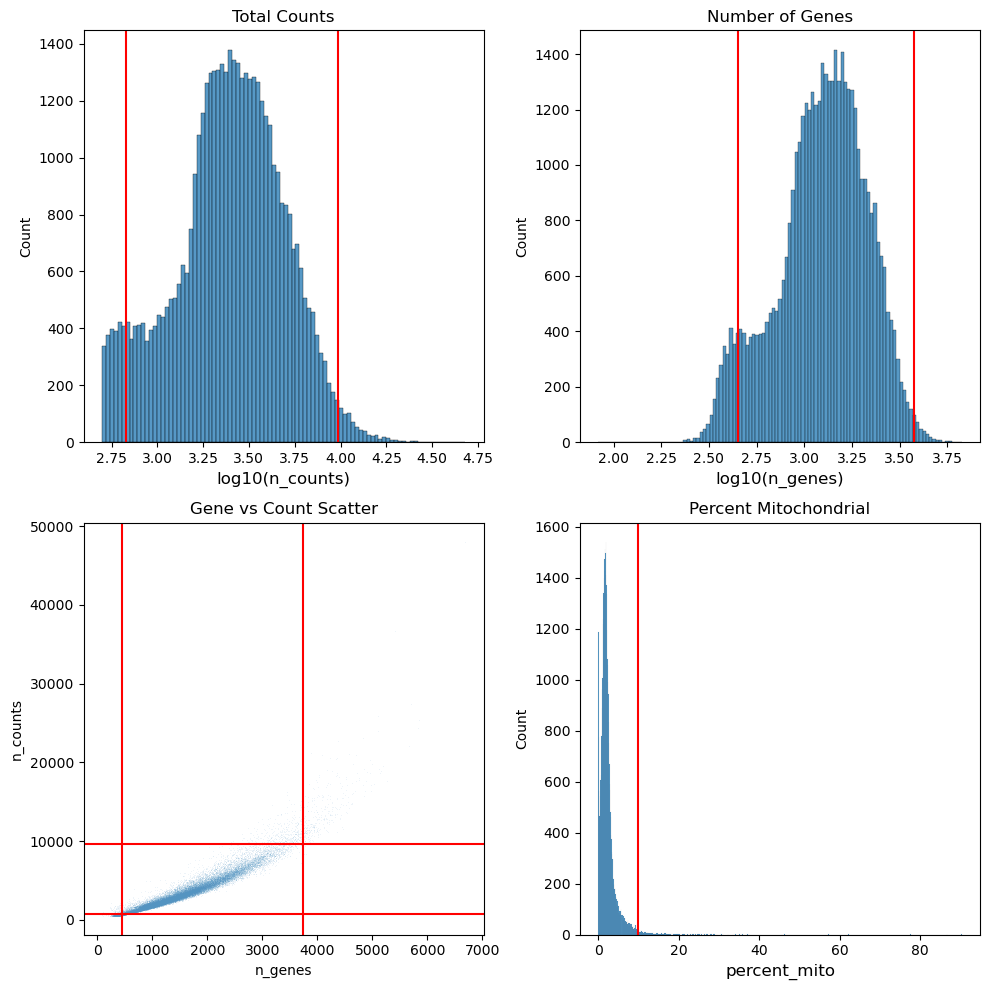

In [15]:
## Visualizating QC Cutoffs ##

MAD = 3

def qc_boundary(counts, k=MAD):
    x = np.log1p(counts)
    mad = median_abs_deviation(x)
    return np.exp(np.median(x) - k*mad), np.exp(np.median(x) + k*mad)

### nUMI and nGene QCs
n_counts_lower, n_counts_upper = qc_boundary(khan_adata.obs.n_counts, k=MAD)
print('n_UMIs lower: %d upper: %d' % (n_counts_lower, n_counts_upper))

n_genes_lower, n_genes_upper = qc_boundary(khan_adata.obs.n_genes, k=MAD)
print('n_genes lower: %d upper: %d' % (n_genes_lower, n_genes_upper))

## Plot Changes to Counts and Genes/Cell Distributions ##

fig, axs = plt.subplots(2, 2, figsize=(10, 10))  # 2x2 grid, adjust size as needed

# Plot 1: log10(n_counts)
sns.histplot(np.log10(khan_adata.obs.n_counts), ax=axs[0, 0])
axs[0, 0].axvline(np.log10(n_counts_lower), color='red')
axs[0, 0].axvline(np.log10(n_counts_upper), color='red')
axs[0, 0].set_xlabel('log10(n_counts)', fontsize=12)
axs[0, 0].set_title("Total Counts")

# Plot 2: log10(n_genes)
sns.histplot(np.log10(khan_adata.obs.n_genes), ax=axs[0, 1])
axs[0, 1].axvline(np.log10(n_genes_lower), color='red')
axs[0, 1].axvline(np.log10(n_genes_upper), color='red')
axs[0, 1].set_xlabel('log10(n_genes)', fontsize=12)
axs[0, 1].set_title("Number of Genes")

# Plot 3: scatter plot of n_genes vs n_counts
sns.scatterplot(x=khan_adata.obs.n_genes, y=khan_adata.obs.n_counts, alpha=0.5, s=0.1, ax=axs[1, 0])
axs[1, 0].axhline(n_counts_lower, color='red')
axs[1, 0].axhline(n_counts_upper, color='red')
axs[1, 0].axvline(n_genes_lower, color='red')
axs[1, 0].axvline(n_genes_upper, color='red')
axs[1, 0].set_xlabel('n_genes')
axs[1, 0].set_ylabel('n_counts')
axs[1, 0].set_title("Gene vs Count Scatter")

# Plot 4: percent_mito
sns.histplot(khan_adata.obs.percent_mito, ax=axs[1, 1])
axs[1, 1].axvline(10, color='red')
axs[1, 1].set_xlabel('percent_mito', fontsize=12)
axs[1, 1].set_title("Percent Mitochondrial")

plt.tight_layout()
plt.show()

n_cells before QC: 45300
n_cells after QC: 45300
mean n_cells before QC 11325.0
mean n_cells after QC 11325.0


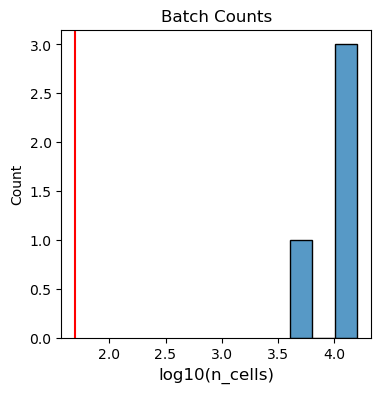

remove 0 batches that have cells less than 50


In [16]:
## Minimum Cell Cutoffs Based on Donor-Batches ##

args_min_n_cells = 50

n_cells_before_qc = khan_adata.obs.library.value_counts().rename_axis('library').reset_index(name='counts')
n_cells_after_qc = khan_adata.obs[khan_adata.obs.passed_qc].library.value_counts().rename_axis('library').reset_index(name='counts')

print('n_cells before QC:', np.sum(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
print('n_cells after QC:', np.sum(n_cells_after_qc[n_cells_after_qc.counts>0].counts))

print('mean n_cells before QC', np.mean(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
print('mean n_cells after QC', np.mean(n_cells_after_qc[n_cells_after_qc.counts>0].counts))

# Plot Distribution of Donor-Batches on Being Greater than Zero
plt.figure(figsize=(4, 4))
plt.title('Batch Counts')
sns.histplot(np.log10(n_cells_before_qc[n_cells_before_qc.counts>0].counts))
plt.axvline(np.log10(args_min_n_cells), color='red')
plt.xlabel('log10(n_cells)', fontsize=12)
plt.show()

### n_cells QC

#identify donor-batches with less than 50 cells of contribution
n_cells_outlier = list(n_cells_after_qc[n_cells_after_qc.counts<args_min_n_cells].library)
# set these to have failed QC as well
khan_adata.obs.loc[khan_adata.obs.library.isin(n_cells_outlier),'passed_qc'] = False
print('remove {0} batches that have cells less than {1}'.format(len(n_cells_outlier), args_min_n_cells))

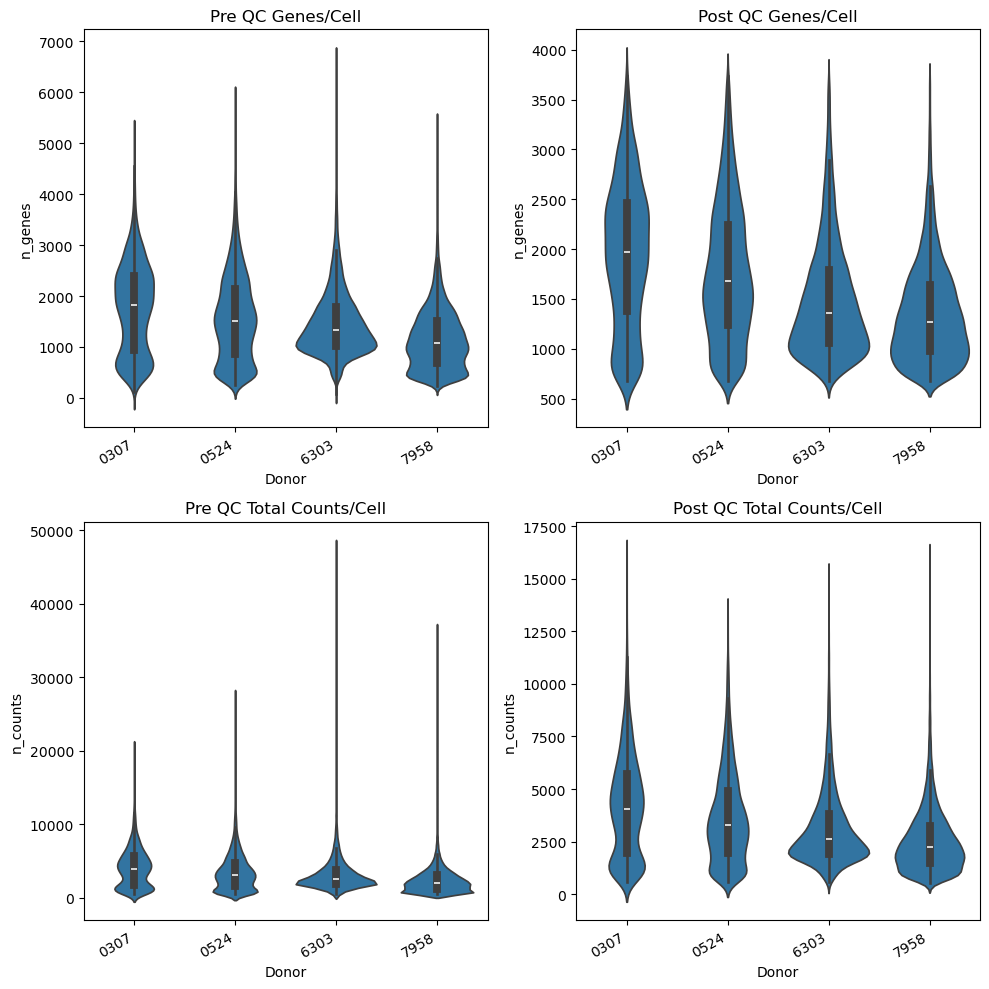

In [17]:
## Trialing QC Cutoffs Before and After ##

## Boolean Cutoffs for UMIs and Genes/Cell ##

counts_filter = (n_counts_lower < khan_adata.obs.n_genes) & (khan_adata.obs.n_genes < n_counts_upper)
genes_filter = (n_genes_lower < khan_adata.obs.n_genes) & (khan_adata.obs.n_genes < n_genes_upper)

# Plot Changes With Violins 

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
sns.violinplot(data=khan_adata.obs, y='n_genes', x='Donor', ax=axes[0])
axes[0].set_title('Pre QC Genes/Cell')
plt.setp(axes[0].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=khan_adata.obs[counts_filter & genes_filter], x='Donor', y='n_genes', ax=axes[1])
axes[1].set_title('Post QC Genes/Cell')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=khan_adata.obs, y='n_counts', x='Donor', ax=axes[2])
axes[2].set_title('Pre QC Total Counts/Cell')
plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')

sns.violinplot(data=khan_adata.obs[khan_adata.obs.passed_qc & genes_filter], x='Donor', y='n_counts', ax=axes[3])
axes[3].set_title('Post QC Total Counts/Cell')
plt.setp(axes[3].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

In [18]:
## Remove Cells That Don't Meet Total Counts/Cell and Genes/Cell Thresholds ##

khan_adata = MultimodalData(UnimodalData(khan_adata, modality="rna"))

#khan_adata = UnimodalData(khan_adata)
pg.qc_metrics(khan_adata, 
              min_genes=n_genes_lower, max_genes=n_genes_upper,
              min_umis=n_counts_lower, max_umis=n_counts_upper,
              mito_prefix='MT-', percent_mito=10)

pg.filter_data(khan_adata)
gc.collect()
khan_adata = khan_adata.to_anndata()

2026-01-31 15:20:36,793 - pegasusio.qc_utils - INFO - After filtration, 41234 out of 45300 cell barcodes are kept in UnimodalData object unknown-rna.
2026-01-31 15:20:36,793 - pegasus.tools.preprocessing - INFO - Function 'filter_data' finished in 0.21s.


In [19]:
## Filter Cells and Genes With Raw Cutoffs #

# store raw counts in layer
khan_adata.layers["raw_counts"] = khan_adata.X

# Note: No cells fail this cutoff affter using MAD based filtration
print((khan_adata.obs.n_genes < 100).sum())
print((khan_adata.var.n_cells < 20).any())

# Doing This For Completeness
sc.pp.filter_cells(khan_adata, min_genes=100)
sc.pp.filter_genes(khan_adata, min_cells=20)

0
False


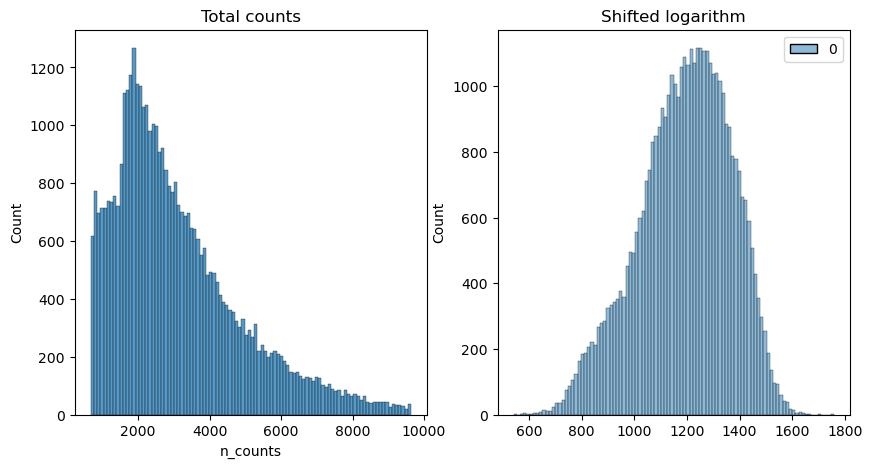

In [20]:
## Log Normalization ##

# normalize 
scales_counts = sc.pp.normalize_total(khan_adata, layer='raw_counts', target_sum=None, inplace=False)

# log1p transform
khan_adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

# set X as log1p normed counts
khan_adata.X = khan_adata.layers["log1p_norm"]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(khan_adata.obs["n_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(khan_adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

2026-01-31 15:20:39,128 - pegasus.tools.utils - INFO - Loaded signatures from GMT file /home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/pegasus/data_files/cell_cycle_human.gmt.
2026-01-31 15:20:39,132 - pegasus.tools.signature_score - INFO - Signature G1/S: 43 out of 43 genes are used in signature score calculation.
2026-01-31 15:20:39,223 - pegasus.tools.signature_score - INFO - Signature G2/M: 54 out of 54 genes are used in signature score calculation.
2026-01-31 15:20:39,359 - pegasus.tools.signature_score - INFO - Function 'calc_signature_score' finished in 0.45s.
2026-01-31 15:20:42,412 - pegasus.tools.preprocessing - INFO - Function 'pca' finished in 1.67s.


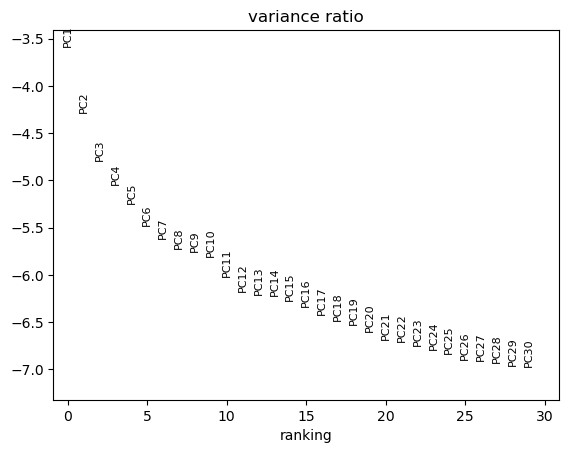

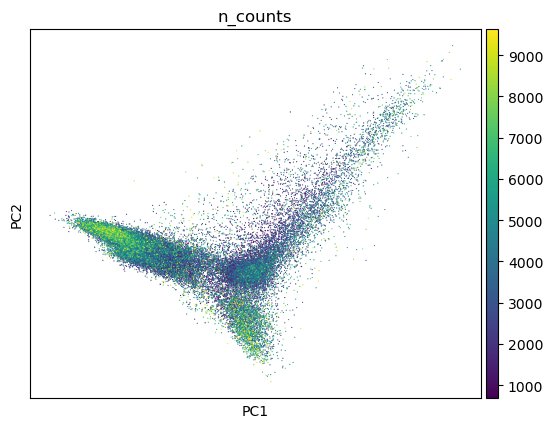

There is 10.7404579860033 variance explained by these components
2026-01-31 15:20:42,722 - pegasus.tools.preprocessing - INFO - Function 'regress_out' finished in 0.06s.
2026-01-31 15:20:42,724 - pegasus.tools.batch_correction - INFO - Start integration using Harmony.
	Initialization is completed.
	Completed 1 / 20 iteration(s).
	Completed 2 / 20 iteration(s).
	Completed 3 / 20 iteration(s).
	Completed 4 / 20 iteration(s).
	Completed 5 / 20 iteration(s).
	Completed 6 / 20 iteration(s).
Reach convergence after 6 iteration(s).
2026-01-31 15:20:47,925 - pegasus.tools.batch_correction - INFO - Function 'run_harmony' finished in 5.20s.
2026-01-31 15:20:51,203 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 3.28s.
2026-01-31 15:20:51,887 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 0.68s.
2026-01-31 15:20:52,672 - pegasus.tools.graph_operations - INFO - Function 'construct_graph' finished in 0.78s.
2026-01-31 15:2

/home/deepak/pixi_envs/pegasus/.pixi/envs/default/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Sat Jan 31 15:20:57 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sat Jan 31 15:21:11 2026 Finished embedding
2026-01-31 15:21:11,375 - pegasus.tools.visualization - INFO - Function 'umap' finished in 15.17s.


In [21]:
# Calculate Highly Variable Genes (not using deviance) ##

if not isinstance(khan_adata, UnimodalData):
    khan_adata = UnimodalData(khan_adata)

## ROUND 0 ##

# calc score requires a float downcast for some reason
khan_adata.X = khan_adata.X.astype('float32')
pg.calc_signature_score(khan_adata, 'cell_cycle_human')

# calculate HVGs on a protein_coding_autosomal only gene list
khan_hvg = khan_adata[:,khan_adata.var.robust_protein_coding_autosome].copy()
khan_hvg = khan_hvg.to_anndata()
hvg = sc.pp.highly_variable_genes(khan_hvg, layer='log1p_norm', n_top_genes=3000, inplace=False, subset=False)
hvg_list = khan_hvg.var.index[hvg.highly_variable].tolist()
del khan_hvg
gc.collect()

# apply that HVG list to your original anndata object
khan_adata.var['highly_variable_features'] = False
khan_adata.var['highly_variable_features'] = khan_adata.var.index.isin(hvg_list)

## Dimensionality Reduction ##

# PCA

if not isinstance(khan_adata, UnimodalData):
    khan_adata = UnimodalData(khan_adata)

pg.pca(khan_adata, n_components=30)
sc.pl.pca_variance_ratio(khan_adata, n_pcs=30, log=True)
sc.pl.pca_scatter(khan_adata.to_anndata(), color="n_counts")
plt.show()

print('There is {0} variance explained by these components'.format(khan_adata.uns['pca']['variance_ratio'].sum()*100))

# # Regress Out ##

pg.regress_out(khan_adata, ['n_counts', 'percent_mito'])

## Harmony  

pg.run_harmony(khan_adata, batch=['Donor'], rep='pca_regressed', max_iter_harmony=20, n_comps=30)

# # UMAP

pg.neighbors(khan_adata, rep='pca_regressed_harmony', use_cache=False, dist='l2', K=100, n_comps=30)
pg.leiden(khan_adata, rep='pca_regressed_harmony', resolution=0.1, class_label='class')
pg.umap(khan_adata, rep='pca_regressed_harmony', n_neighbors=15, rep_ncomps=30)
plt.show()

khan_adata = khan_adata.to_anndata()

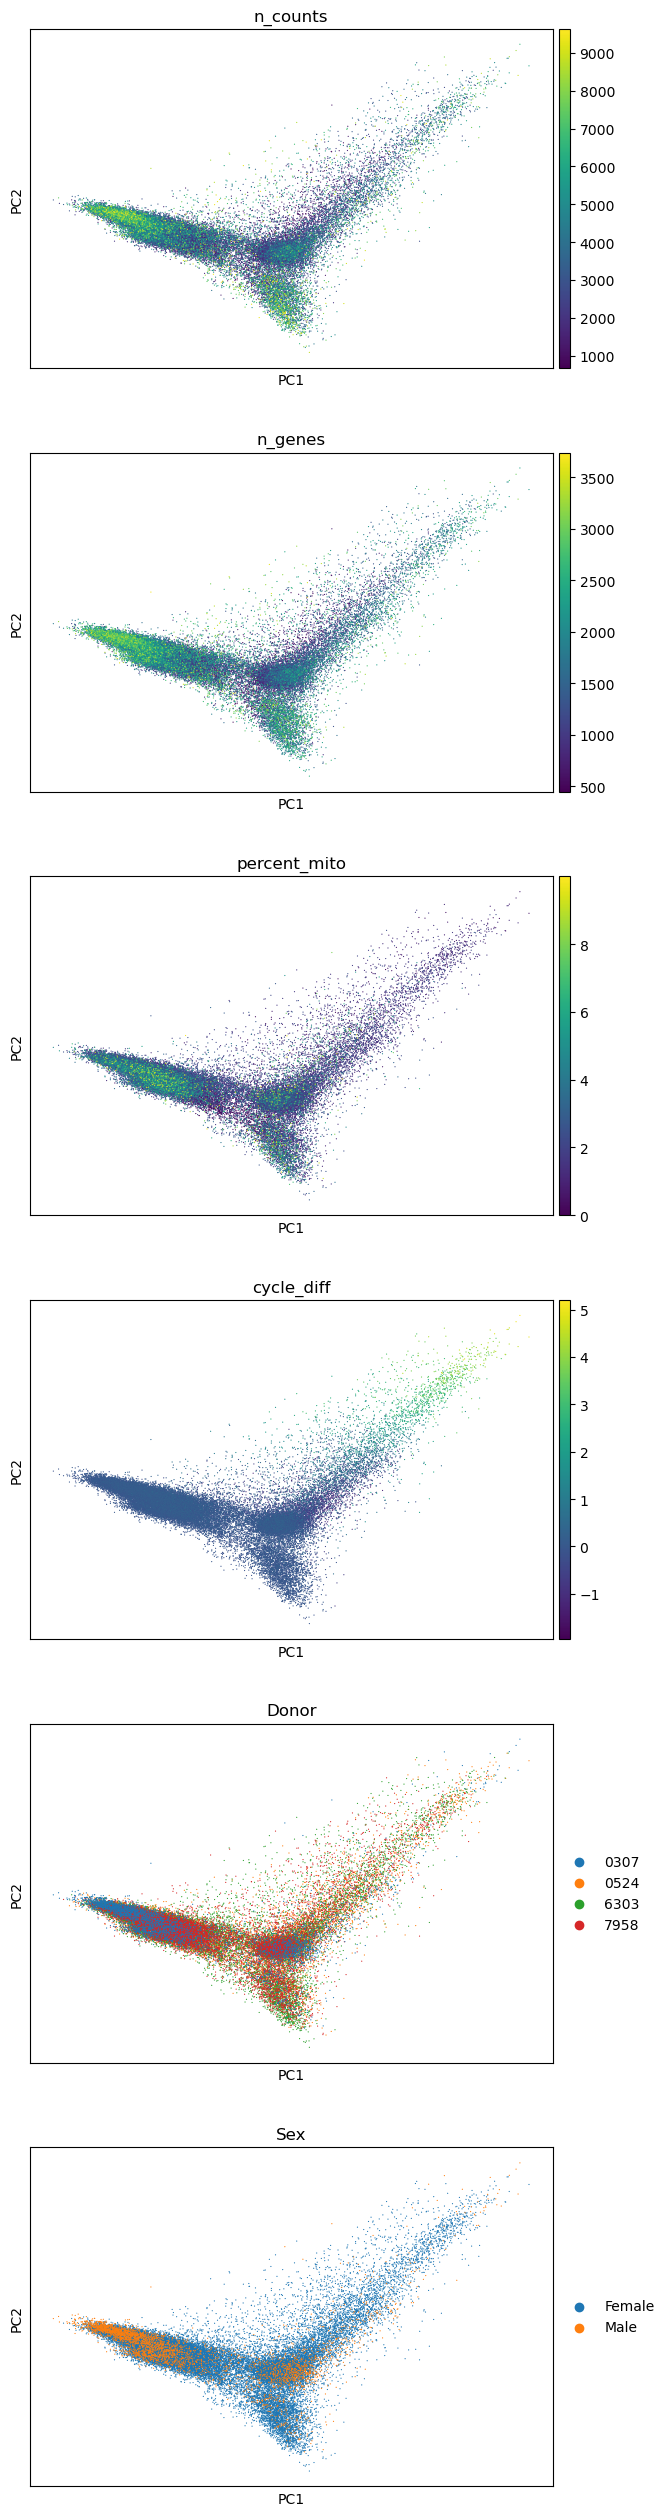

In [22]:
sc.pl.pca(khan_adata, color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Sex'], ncols=1)

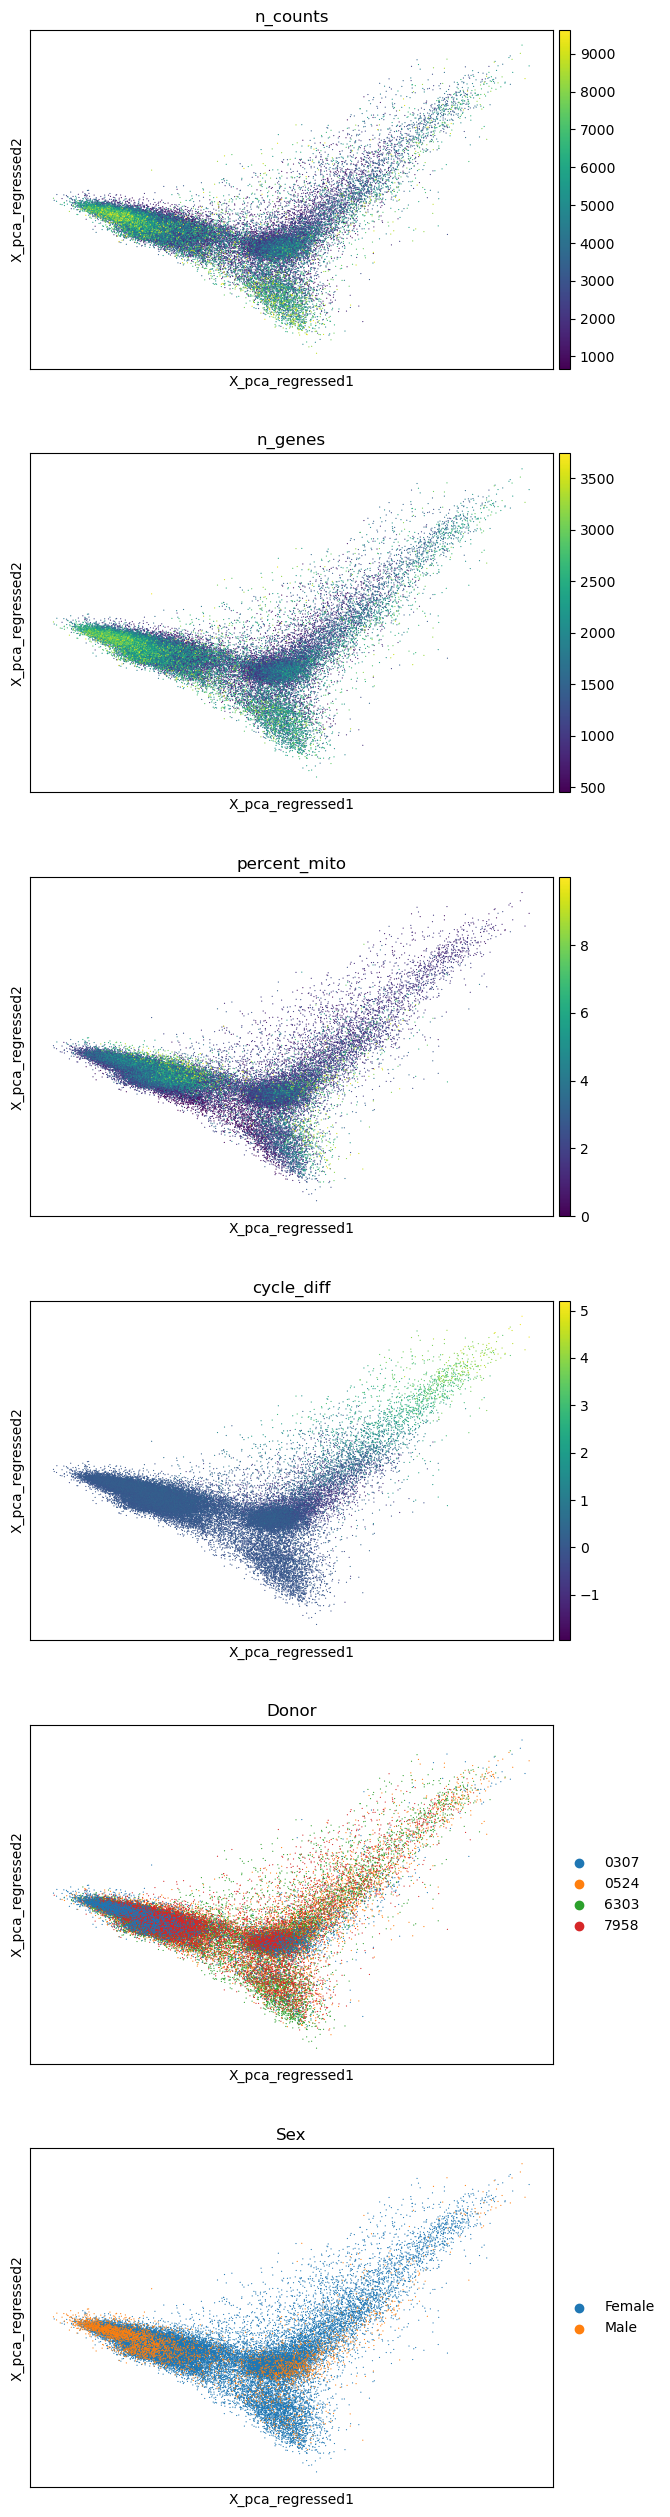

In [23]:
sc.pl.embedding(khan_adata, basis='X_pca_regressed', 
                color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Sex'], ncols=1)

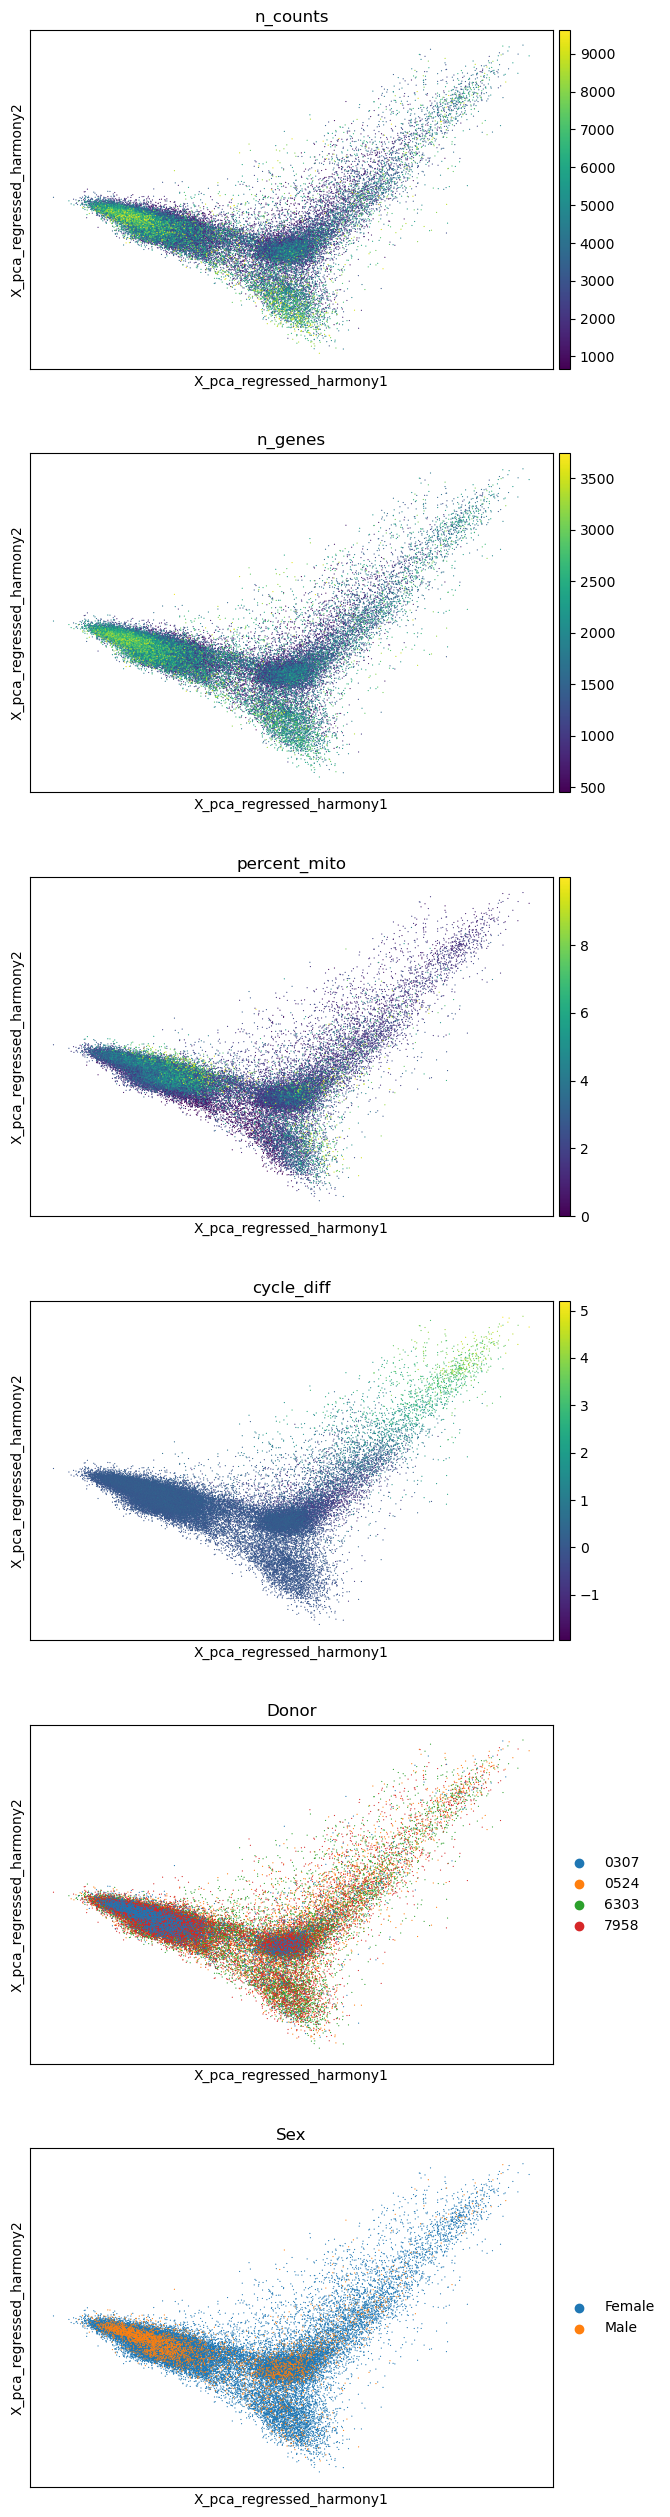

In [24]:
sc.pl.embedding(khan_adata, basis='X_pca_regressed_harmony', 
                color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Sex'], ncols=1)

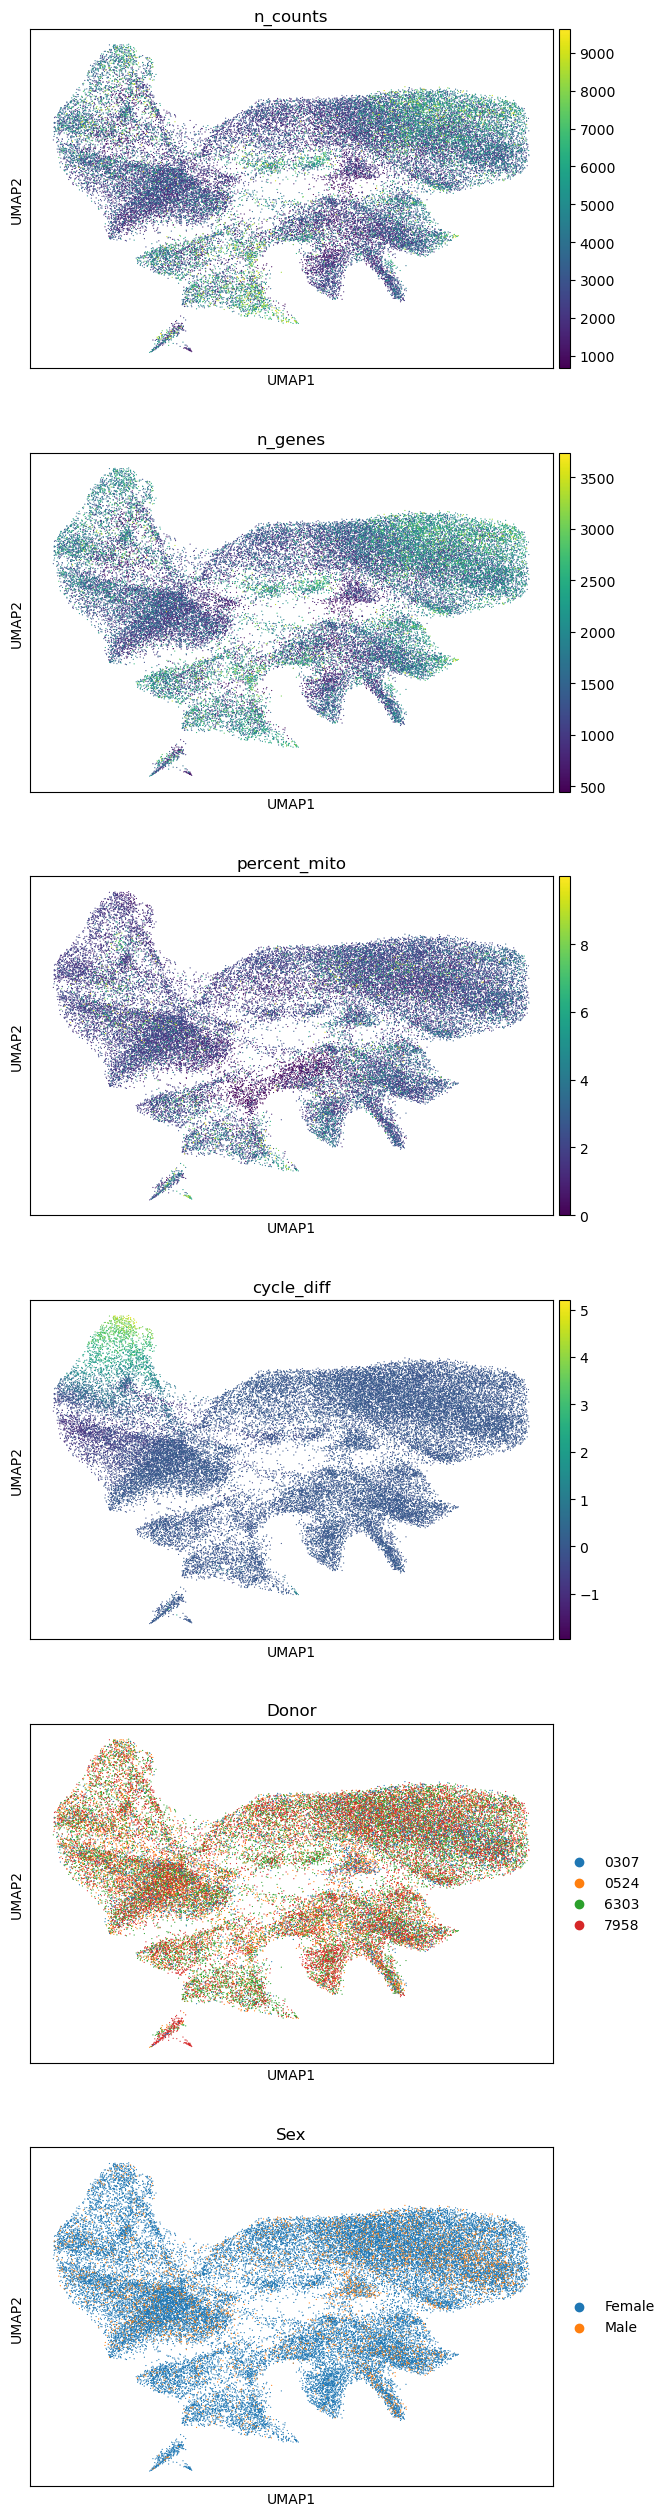

In [25]:
sc.pl.umap(khan_adata, color=["n_counts", "n_genes", "percent_mito", 'cycle_diff', 'Donor', 'Sex'], ncols=1)

In [29]:
## Save Step ##

khan_adata.write_h5ad(os.path.join('/mnt/sdb/scz_meta_analysis_processed/khan_pasca/anndata_objs/khan_qc.h5ad'))

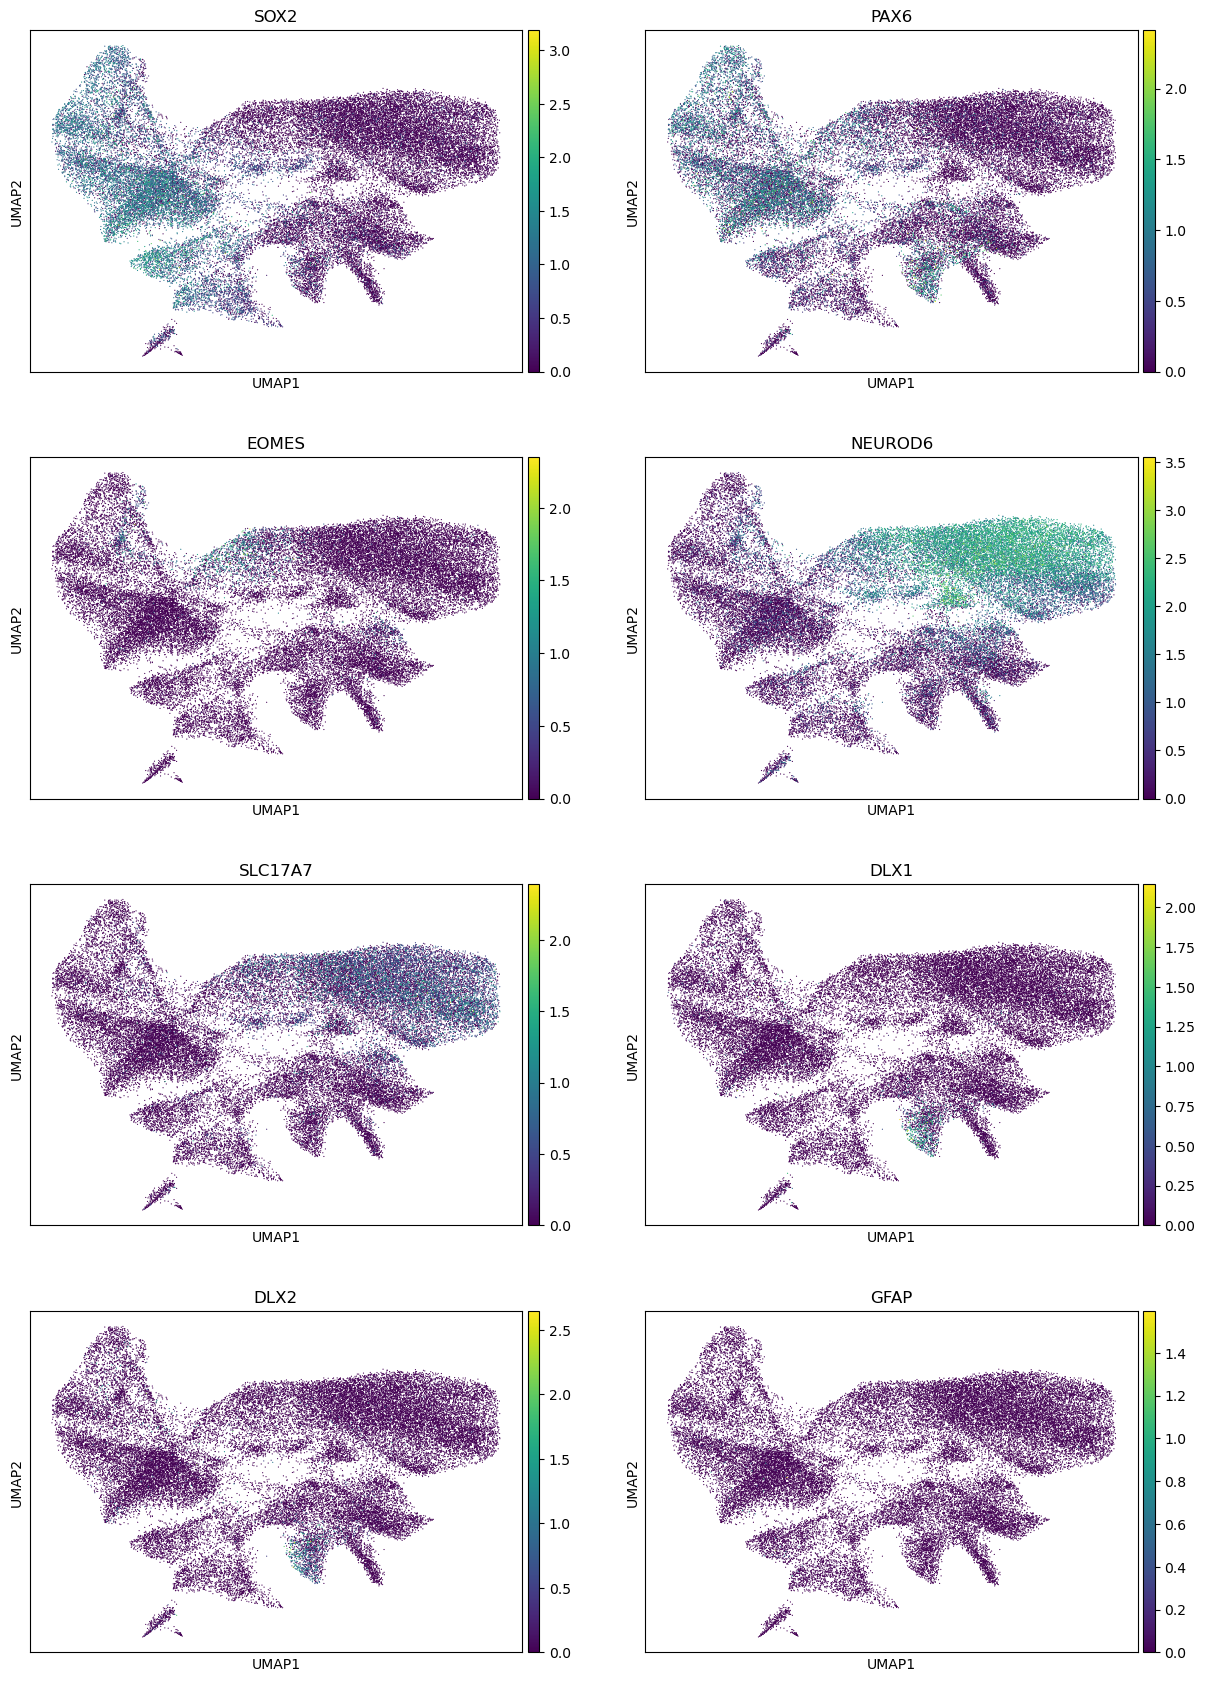

In [39]:
sc.pl.umap(khan_adata, color=['SOX2', 'PAX6', 'EOMES', 'NEUROD6', 'SLC17A7', 'DLX1', 'DLX2', 'GFAP'], ncols=2)